In [1]:
import torch
import os
from utilities import *
device = torch.device('cpu')

c:\Users\runan\kan-robustness-scaling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seeds = [0, 1, 42] 
noise_levels = [0, 0.02, 0.04, 0.1, 0.2] 
n_train = 1000
n_test = 1000
steps = 200
grids = [3, 5, 10, 20, 50, 100]
outlier_pcts = [0, 0.5, 1, 2, 5]
lr = 1.0
k = 3

In [13]:
def train_kan_on_noise(seed, noise, dim, data):
    dataset_path = os.path.join("datasets", f"seed {seed}", f"{data}_dataset_dim{dim}_seed{seed}.pt")
    if not os.path.exists(dataset_path):
        dataset = generate_dataset(dim=dim, seed=seed, data=data, n_train=n_train, n_test=n_test)
    else:
        dataset = torch.load(dataset_path, map_location=torch.device('cpu'))
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    if data == 'A':
        std = 0.3885
    elif data == 'C':
        std = 0.3333
    sigma = float(noise * std)
    print(sigma)
    dataset['train_input'] = dataset['train_input'] + sigma * torch.randn_like(dataset['train_input'])
    dataset['test_input'] = dataset['test_input'] + sigma * torch.randn_like(dataset['test_input'])
    dataset['train_label'] = dataset['train_label'] + sigma * torch.randn_like(dataset['train_label'])
    dataset['test_label'] = dataset['test_label'] + sigma * torch.randn_like(dataset['test_label'])

    width = [dim, 1, 1]

    result = {}
    print(f'\nSeed {seed} | noise={sigma} | dim={dim} | data={data}')
    # result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)

    # print(f'Seed {seed} | noise={sigma}: running dynamic KAN')
    # result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)

    # print(f'Seed {seed} | noise={sigma}: running MLP')
    # mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    # result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)

    
    # dir = os.path.join('4-results-noise', f'seed-{seed}')
    # os.makedirs(dir, exist_ok=True)
    # torch.save(result, os.path.join(dir, f'{data}_dim{dim}_noise_{sigma:.3f}.pt'))
    return result


In [24]:
results = {}
for noise in noise_levels:
    # train_kan_on_noise(0, noise, 100, 'C')
    train_kan_on_noise(0, noise, 5, 'C')
    # train_kan_on_noise(seed, noise, 5, 'A')

0.0

Seed 0 | noise=0.0 | dim=5 | data=C
0.006666

Seed 0 | noise=0.006666 | dim=5 | data=C
0.013332

Seed 0 | noise=0.013332 | dim=5 | data=C
0.03333

Seed 0 | noise=0.03333 | dim=5 | data=C
0.06666

Seed 0 | noise=0.06666 | dim=5 | data=C


In [47]:
def train_kan_on_outliers(seed, outlier_pct, dim, data):
    """Train KAN/MLP with a percentage of labels replaced by 1000% of max value (outlier injection)."""
    dataset = torch.load(os.path.join('datasets', f'seed {seed}', f'{data}_dataset_dim{dim}_seed{seed}.pt'), map_location='cpu')
    
    # Clone to avoid modifying original
    dataset = {k: v.clone() for k, v in dataset.items()}
    
    outlier_pct_float = float(outlier_pct)
    if data == 'A':
        max_val = math.exp(math.sqrt(dim)/2.0)
    elif data == 'C':
        max_val = math.sqrt(dim)
    outlier_val = 1 * max_val 
    
    # Inject outliers into train labels
    n_train_outliers = int(np.ceil(dataset['train_label'].shape[0] * outlier_pct_float / 100.0))
    if n_train_outliers > 0:
        train_indices = np.random.choice(dataset['train_label'].shape[0], n_train_outliers, replace=False)
        dataset['train_label'][train_indices] = outlier_val
    
    # Inject outliers into test labels
    n_test_outliers = int(np.ceil(dataset['test_label'].shape[0] * outlier_pct_float / 100.0))
    if n_test_outliers > 0:
        test_indices = np.random.choice(dataset['test_label'].shape[0], n_test_outliers, replace=False)
        dataset['test_label'][test_indices] = outlier_val
    
    width = [dim, 1, 1]
    
    result = {}
    print(f'\nSeed {seed} | outlier%={outlier_pct_float}: running static KAN')
    result['static'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=True, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running dynamic KAN')
    result['dynamic'] = train_kan(width=width, dataset=dataset, steps=steps, grids=grids, lr=lr, seed=seed, static=False, k=k, device=device)
    
    print(f'Seed {seed} | outlier%={outlier_pct_float}: running MLP')
    mlp_hidden_width = math.ceil((10*dim+11)/(dim+2)) - 1
    result['mlp'] = train_mlp(width=[dim, mlp_hidden_width, 1], dataset=dataset, steps=steps, lr=lr, seed=seed)
    
    dir = os.path.join('4-results-noise-extreme', f'seed-{seed}')
    os.makedirs(dir, exist_ok=True)
    torch.save(result, os.path.join(dir, f'{data}_dim{dim}_outlier_{outlier_pct_float:.1f}pct.pt'))
    return result


In [ ]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'A')
        train_kan_on_outliers(seed, outlier_pct, 5, 'C')
        train_kan_on_outliers(seed, outlier_pct, 100, 'C')


In [22]:
import os
import glob
import torch

def load_kan_results(data_name,  dim):

    compiled_results = {}
    
    search_pattern = os.path.join('4-results-noise', 'seed-*', f'{data_name}_dim{dim}_noise_*.pt')
    matching_files = glob.glob(search_pattern)
    
    if not matching_files:
        print('No files found for equation')
        return compiled_results

    for file_path in matching_files:
        path_parts = file_path.split(os.sep)
        seed_str = [part for part in path_parts if part.startswith('seed-')][0]
        seed = int(seed_str.split('-')[1])
        filename = os.path.basename(file_path)
        try:
            sigma_str = filename.split('_noise_')[1].replace('.pt', '')
            sigma = float(sigma_str)
        except (IndexError, ValueError):
            sigma = filename # Fallback to string if naming structure differs
            
        # Load the PyTorch file
        result_data = torch.load(file_path, map_location='cpu', weights_only=False)
        
        # Organize into the compiled dictionary
        if seed not in compiled_results:
            compiled_results[seed] = {}
            
        compiled_results[seed][sigma] = result_data

    print(f"Successfully loaded {len(matching_files)} result file(s).")
    return compiled_results

In [25]:
C_dim100 = load_kan_results('C', 100)
C_dim5 = load_kan_results('C', 5)
A_dim5 = load_kan_results('A', 5)

Successfully loaded 15 result file(s).
Successfully loaded 15 result file(s).
Successfully loaded 15 result file(s).


In [24]:
seeds = [0, 1, 42]

In [31]:
print(experiments[seeds[0]][0].keys())
print(experiments[seeds[1]].keys())
print(experiments[seeds[2]].keys())

dict_keys([0, 1, 42])


AttributeError: 'tuple' object has no attribute 'keys'

In [26]:
def plot(experiments, seeds):
    # Create subplots based on the number of experiments loaded
    fig, axes = plt.subplots(1, len(experiments), figsize=(5 * len(experiments), 5))
    if len(experiments) == 1:
        axes = [axes] # Ensure axes is iterable if only 1 experiment is passed

    for ax, (results, data, dim) in zip(axes, experiments):
        noise_values = sorted(results[seeds[0]].keys())
        print(results[seeds[0]].keys())
        print(results[seeds[1]].keys())
        print(results[seeds[2]].keys())
        
        static_r2 = np.array([[results[s][n]['static']['r2s'][-1] for n in noise_values] for s in seeds])
        dynamic_r2 = np.array([[results[s][n]['dynamic']['r2s'][-1] for n in noise_values] for s in seeds])
        
        # Use np.nan instead of None for MLP to allow for easy mathematical aggregation
        mlp_r2 = np.array([[results[s][n]['mlp']['r2s'][-1] if 'r2s' in results[s][n]['mlp'] else np.nan for n in noise_values] for s in seeds], dtype=float)

        # Plot lines (Mean) and min-max error bands (fill_between)
        ax.plot(noise_values, static_r2.mean(axis=0), marker='s', label='Static KAN')
        ax.fill_between(noise_values, static_r2.min(axis=0), static_r2.max(axis=0), alpha=0.2)

        ax.plot(noise_values, dynamic_r2.mean(axis=0), marker='^', label='Dynamic KAN')
        ax.fill_between(noise_values, dynamic_r2.min(axis=0), dynamic_r2.max(axis=0), alpha=0.2)

        if not np.isnan(mlp_r2).all():
            ax.plot(noise_values, np.nanmean(mlp_r2, axis=0), marker='o', label='MLP')
            ax.fill_between(noise_values, np.nanmin(mlp_r2, axis=0), np.nanmax(mlp_r2, axis=0), alpha=0.2)
            
        # Formatting for the specific subplot
        ax.set_xlabel('Noise $\sigma$')
        ax.set_ylabel('$R^2$')
        ax.set_title(f'Data {data}, dim {dim}')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    # Global formatting
    fig.suptitle('Noise sensitivity across datasets')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    fig.savefig('noise_sensitivity_all_subfigures.png', bbox_inches='tight', dpi=300)

<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
C:\Users\runan\AppData\Local\Temp\ipykernel_35416\820800824.py:31: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Noise $\sigma$')


In [42]:
seeds = [0, 1, 42]

dict_keys([0.0, 0.008, 0.016, 0.039, 0.078])
dict_keys([0.0, 0.008, 0.016, 0.039, 0.078])
dict_keys([0.0, 0.008, 0.016, 0.039, 0.078])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])
dict_keys([0.0, 0.007, 0.013, 0.033, 0.067])


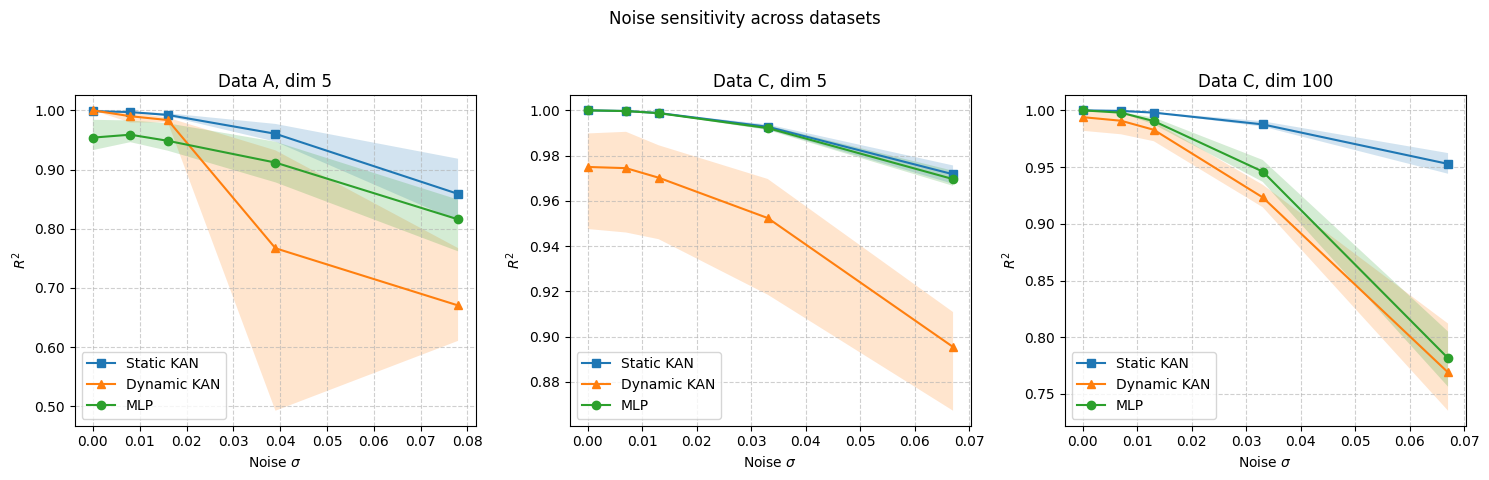

In [27]:
experiments = [
    (A_dim5, 'A', 5),
    (C_dim5, 'C', 5),
    (C_dim100, 'C', 100)
]

# Run the plot function with the list
plot(experiments, seeds)

In [57]:
print(C_dim5[0].keys())

dict_keys([0.0, 0.012, 0.023, 0.058, 0.116])


In [ ]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'B')

In [99]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 5, 'C')


Seed 0 | outlier%=0.0: running static KAN


Seed 0 | outlier%=0.0: running dynamic KAN


Seed 0 | outlier%=0.0: running MLP


| train_loss: 7.24e-05 | test_loss: 7.42e-05 | reg: 2.56e+01 | : 100%|█| 200/200 [00:07<00:00, 26.49



Seed 0 | outlier%=0.5: running static KAN


...

| train_loss: 2.79e+00 | test_loss: 2.96e+00 | reg: 3.38e+02 | : 100%|█| 200/200 [00:20<00:00,  9.88



Seed 0 | outlier%=5.0: running static KAN


Seed 0 | outlier%=5.0: running dynamic KAN


Seed 0 | outlier%=5.0: running MLP


| train_loss: 4.23e+00 | test_loss: 4.77e+00 | reg: 6.27e+02 | : 100%|█| 200/200 [00:25<00:00,  7.71


In [100]:
for seed in seeds:
    for outlier_pct in outlier_pcts:
        train_kan_on_outliers(seed, outlier_pct, 100, 'C')


Seed 0 | outlier%=0.0: running static KAN


Seed 0 | outlier%=0.0: running dynamic KAN


Seed 0 | outlier%=0.0: running MLP


| train_loss: 7.67e-05 | test_loss: 5.24e-04 | reg: 1.02e+02 | : 100%|█| 200/200 [00:20<00:00,  9.70



Seed 0 | outlier%=0.5: running static KAN


...

| train_loss: 3.40e-03 | test_loss: 4.51e+00 | reg: 4.93e+02 | : 100%|█| 200/200 [00:18<00:00, 10.64



Seed 0 | outlier%=5.0: running static KAN


Seed 0 | outlier%=5.0: running dynamic KAN


Seed 0 | outlier%=5.0: running MLP


| train_loss: 1.29e-02 | test_loss: 8.69e+00 | reg: 9.08e+02 | : 100%|█| 200/200 [00:19<00:00, 10.01
